In [17]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

!pip install opendatasets --upgrade --quiet
import opendatasets as od

od.download("https://www.kaggle.com/datasets/ealaxi/paysim1")

Skipping, found downloaded files in "./paysim1" (use force=True to force download)


In [18]:

df = pd.read_csv("paysim1/PS_20174392719_1491204439457_log.csv")

df_clean = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()
df_clean.drop(columns=['nameOrig', 'nameDest', 'isFlaggedFraud'], inplace=True, errors='ignore')


# Exploratory Data Analysis (EDA)

## 1. Dataset Overview

Before preprocessing and model training, we examine the dataset to understand its structure, feature types, and overall characteristics. This helps identify the available information and guides subsequent preprocessing and feature engineering decisions.

In [19]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nBasic Statistics:")
display(df.describe())

DATASET OVERVIEW
Rows    : 6,362,620
Columns : 11

Column Names:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

Data Types:
step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

Basic Statistics:


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


### Observations

- The dataset contains approximately **6.3 million** financial transactions.
- It consists of **11 original features**, including transaction details, account balances, identifiers, and the target variable (`isFraud`).
- Both numerical and categorical attributes are present.
- The `isFraud` column serves as the target variable for binary classification.
- Customer identifiers (`nameOrig`, `nameDest`) are unique identifiers rather than informative predictive features.

### Engineering Decision

Based on the dataset structure:

- Identifier columns (`nameOrig` and `nameDest`) will be removed during preprocessing as they represent unique account identifiers and do not provide meaningful predictive information.
- The `isFlaggedFraud` feature will be removed as it is a PaySim-specific simulator flag rather than an intrinsic transaction characteristic, making it unsuitable for building a generalizable fraud detection model.
- The target variable (`isFraud`) will be separated from the input features before model training.

## 2. Missing Value Analysis

Missing values can impact model performance and may require imputation or data cleaning. We first examine the dataset to determine whether missing values are present before deciding on any preprocessing strategy.

In [20]:
print("=" * 60)
print("MISSING VALUE ANALYSIS")
print("=" * 60)

missing = df.isnull().sum()

display(missing)

print(f"\nTotal Missing Values: {missing.sum()}")

MISSING VALUE ANALYSIS


,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0



Total Missing Values: 0


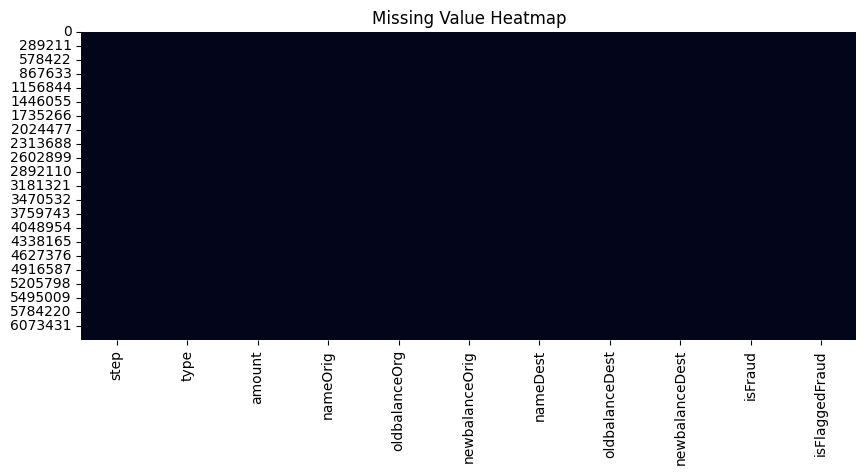

In [21]:
plt.figure(figsize=(10,4))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Value Heatmap")
plt.show()

### Engineering Decision

Since the dataset contains no missing values, no imputation or row removal was required. All preprocessing efforts were therefore focused on feature selection and feature engineering rather than data completion.

## 3. Class Distribution

Fraud detection datasets are typically highly imbalanced, with legitimate transactions greatly outnumbering fraudulent ones. We analyze the class distribution to understand the severity of this imbalance and determine whether resampling techniques are required.

CLASS DISTRIBUTION
isFraud
0    6354407
1       8213
Name: count, dtype: int64
Fraud Percentage: 0.1291%
Legitimate Percentage: 99.8709%


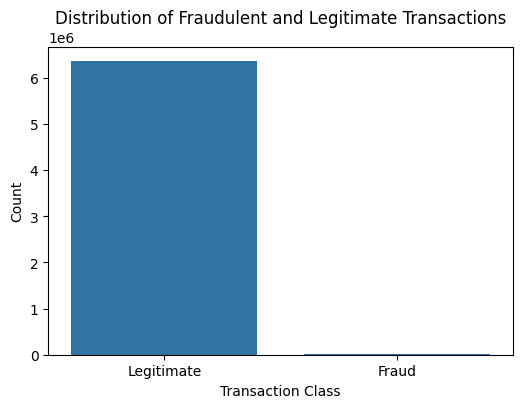

In [22]:
print("=" * 60)
print("CLASS DISTRIBUTION")
print("=" * 60)

print(df["isFraud"].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="isFraud")

plt.title("Distribution of Fraudulent and Legitimate Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Count")

plt.xticks([0,1],["Legitimate","Fraud"])

fraud_percentage = (df["isFraud"].mean()) * 100

print(f"Fraud Percentage: {fraud_percentage:.4f}%")
print(f"Legitimate Percentage: {100-fraud_percentage:.4f}%")

plt.show()

### Observations

- The dataset is highly imbalanced, with fraudulent transactions representing only a very small fraction of the total data.
- Most transactions belong to the legitimate class, making overall accuracy an unreliable evaluation metric.
- Without addressing this imbalance, the model would be biased toward predicting legitimate transactions.

### Engineering Decisions

- SMOTE was applied exclusively to the training set to generate synthetic fraud samples while preventing data leakage.
- Evaluation focused on Precision, Recall, F1-Score and PR-AUC instead of accuracy, as these metrics better reflect performance on highly imbalanced datasets.

## 4. Transaction Type Analysis

Different transaction types may exhibit different behavioral patterns. We analyze the frequency of each transaction type and investigate whether fraud is concentrated within specific categories.

TRANSACTION TYPE DISTRIBUTION
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64


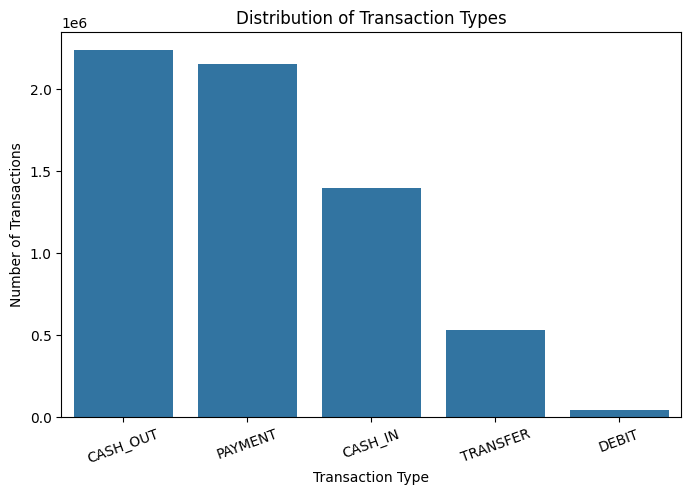

In [23]:
print("=" * 60)
print("TRANSACTION TYPE DISTRIBUTION")
print("=" * 60)

print(df["type"].value_counts())

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="type", order=df["type"].value_counts().index)

plt.title("Distribution of Transaction Types")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=20)

plt.show()

isFraud,0,1
type,,
CASH_IN,1399284,0
CASH_OUT,2233384,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,528812,4097


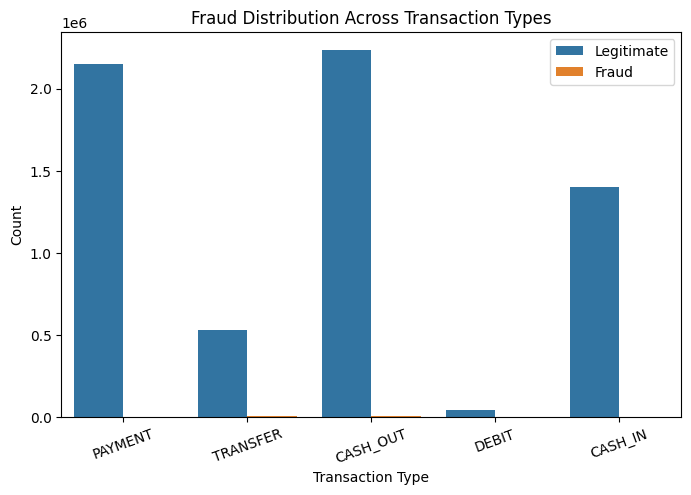

In [24]:
fraud_by_type = pd.crosstab(df["type"], df["isFraud"])

display(fraud_by_type)

plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x="type",
    hue="isFraud"
)

plt.title("Fraud Distribution Across Transaction Types")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.legend(["Legitimate", "Fraud"])

plt.xticks(rotation=20)

plt.show()

### Observations

- Fraudulent transactions are observed exclusively in the **TRANSFER** and **CASH_OUT** transaction types.
- PAYMENT, DEBIT, and CASH_IN transactions contain no fraudulent instances in the PaySim dataset.
- This indicates that fraud within PaySim is concentrated in only a subset of transaction categories.

### Engineering Decisions

- The dataset was filtered to retain only **TRANSFER** and **CASH_OUT** transactions before model training.
- Removing transaction types that never contain fraud reduces unnecessary data and allows the model to focus on informative transaction categories.
- This decision is specific to the characteristics of the PaySim dataset and should be re-evaluated when working with other datasets.

## 5. Transaction Amount Analysis

Transaction amount is one of the most important financial attributes in fraud detection. We analyze its distribution for both legitimate and fraudulent transactions to determine whether it carries predictive information.

TRANSACTION AMOUNT ANALYSIS


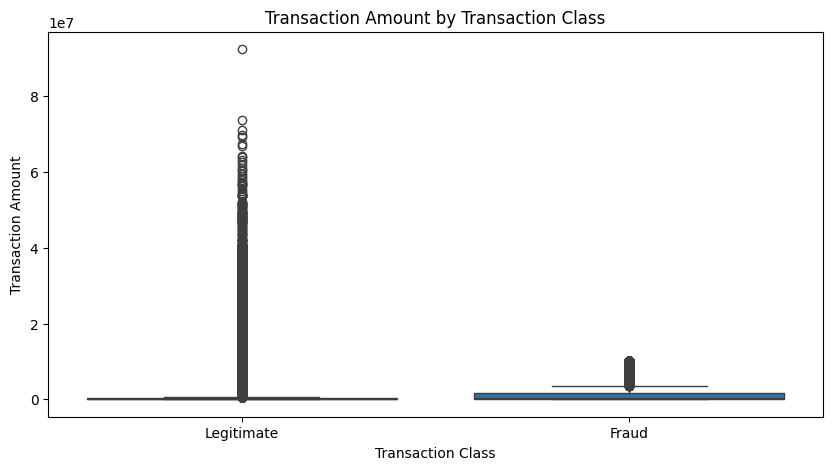

In [25]:
print("=" * 60)
print("TRANSACTION AMOUNT ANALYSIS")
print("=" * 60)

plt.figure(figsize=(10,5))

sns.boxplot(
    data=df_clean,
    x="isFraud",
    y="amount"
)

plt.xticks([0,1],["Legitimate","Fraud"])
plt.xlabel("Transaction Class")
plt.ylabel("Transaction Amount")
plt.title("Transaction Amount by Transaction Class")

plt.show()

### Observations

- Transaction amounts exhibit a highly skewed distribution for both legitimate and fraudulent transactions.
- Legitimate transactions contain a substantial number of high-value outliers.
- Fraudulent transactions tend to occur within a relatively narrower transaction amount range compared to the full range of legitimate transactions.
- Transaction amount alone is insufficient to distinguish fraudulent transactions and must be interpreted alongside other transactional features.

### Engineering Decisions

- The `amount` feature was retained as an important predictor because it contributes useful information when combined with other transaction features.
- A tree-based model (Random Forest) was selected because it can learn interactions between multiple features rather than relying on transaction amount alone.

## 6. Correlation Analysis

Correlation analysis helps identify relationships between numerical features. While Random Forest does not require independent features, understanding feature relationships provides insight into the dataset and supports feature engineering decisions.

CORRELATION ANALYSIS


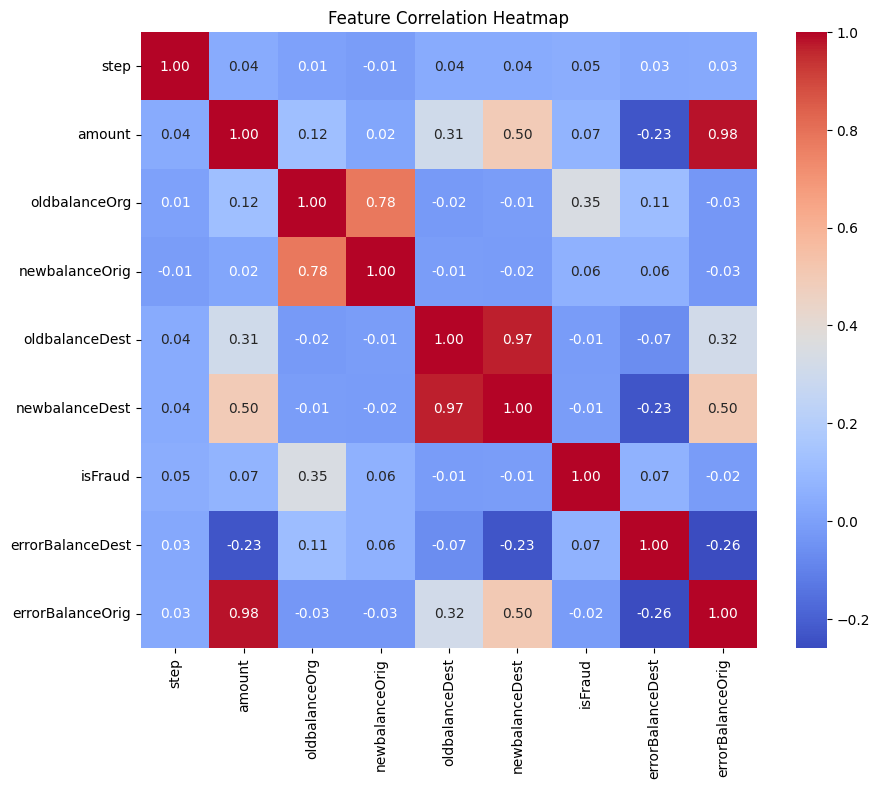

In [26]:
print("=" * 60)
print("CORRELATION ANALYSIS")
print("=" * 60)

plt.figure(figsize=(10,8))

corr = df_clean.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)

plt.title("Feature Correlation Heatmap")

plt.show()

### Observations

- `oldbalanceOrg` and `newbalanceOrig` exhibit a strong positive correlation (0.78), reflecting the natural relationship between sender balances before and after a transaction.
- `oldbalanceDest` and `newbalanceDest` are also highly correlated (0.97), indicating consistent balance updates for destination accounts.
- No individual feature shows a strong linear correlation with the target variable (`isFraud`), suggesting that fraud detection depends on the interaction of multiple transaction attributes rather than a single feature.
- The engineered feature `errorBalanceOrig` (or `errorBalanceDest`, depending on your full heatmap) exhibits distinct relationships with balance-related features, indicating that feature engineering captures additional transactional information beyond the original dataset.

### Engineering Decisions

- A tree-based ensemble model (Random Forest) was selected because it effectively captures complex, non-linear interactions between multiple features.
- Feature engineering was incorporated to expose balance inconsistencies that are not directly represented by the original dataset features.
- Correlation analysis was used for understanding feature relationships rather than feature elimination, as Random Forest is robust to correlated predictors.

## 7. Feature Engineering Analysis

To capture inconsistencies in account balances that may indicate suspicious transactions, two additional features were engineered based on balance conservation rules.

These engineered features were analyzed to understand their relationship with fraudulent and legitimate transactions.

In [27]:


df_clean["errorBalanceOrig"] = (
    df_clean["newbalanceOrig"] +
    df_clean["amount"] -
    df_clean["oldbalanceOrg"]
)

df_clean["errorBalanceDest"] = (
    df_clean["oldbalanceDest"] +
    df_clean["amount"] -
    df_clean["newbalanceDest"]
)

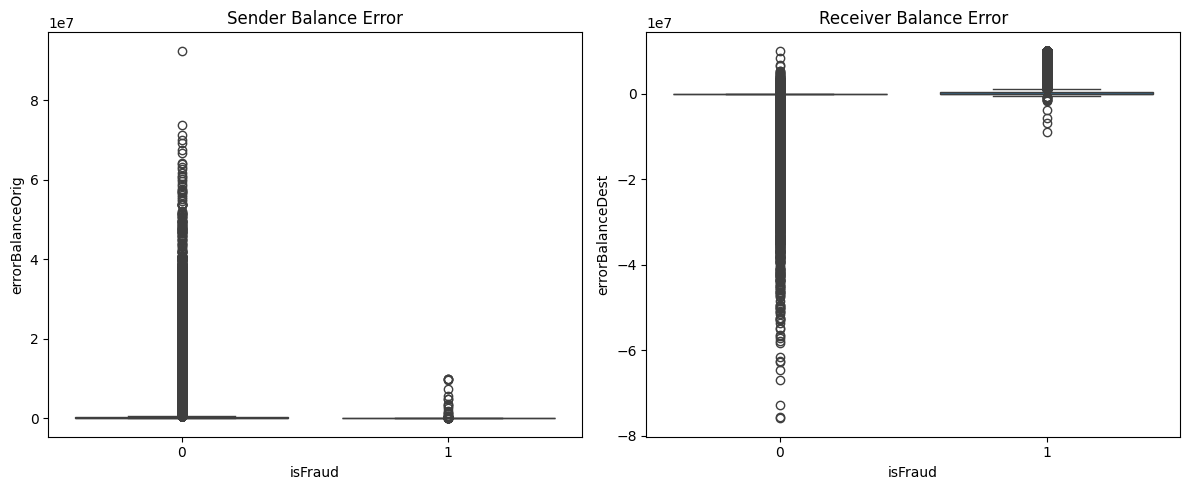

In [28]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(
    data=df_clean,
    x="isFraud",
    y="errorBalanceOrig"
)

plt.title("Sender Balance Error")

plt.subplot(1,2,2)
sns.boxplot(
    data=df_clean,
    x="isFraud",
    y="errorBalanceDest"
)

plt.title("Receiver Balance Error")

plt.tight_layout()
plt.show()

### Observations

- Both engineered features are centered close to zero for most transactions.
- Significant balance inconsistencies are present in both legitimate and fraudulent transactions.
- Legitimate transactions exhibit a larger number of extreme outliers than fraudulent transactions.
- This suggests that these balance-error features reflect simulator-specific behaviour and should not be interpreted as standalone indicators of fraud.

### Engineering Decisions

- The engineered balance-error features were retained because they provide additional information when combined with other transaction attributes.
- Random Forest was selected because it can learn interactions between multiple features rather than relying on a single engineered feature.
- The observed simulator-specific behaviour is acknowledged as a limitation of the PaySim dataset.

# EDA Summary

## Key Findings

- The dataset contains over 6.3 million financial transactions with no missing values.
- Fraudulent transactions are highly imbalanced, motivating the use of SMOTE during training.
- Fraud occurs exclusively within the TRANSFER and CASH_OUT transaction types in the PaySim dataset, justifying dataset filtering.
- Transaction amount alone is insufficient to distinguish fraudulent transactions.
- Correlation analysis indicates that fraud detection depends on interactions among multiple features rather than a single predictor.
- Two engineered balance-error features significantly improved model performance, as confirmed by an ablation study, while also exhibiting simulator-specific behaviour that is acknowledged as a limitation.
- These findings directly informed the preprocessing pipeline and the selection of a Random Forest classifier.